# Nonlinear Dynamics: Lorenz Regime Classification

Classify Lorenz-system parameter regimes from short trajectory statistics. The quantum model uses package angle embedding inside a precomputed quantum kernel and is benchmarked against logistic regression.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** The Lorenz system is a nonlinear dynamical system with parameter-dependent behavior. The notebook integrates short trajectories and classifies which Rayleigh-parameter regime generated each trajectory.

**Explicit variables.** `sigma`, `rho`, and `beta` are Lorenz-system parameters. `dt` is the integration time step. `steps` is the number of integration steps. `trajectory` stores simulated states `[x(t), y(t), z(t)]`. `tail` is the final trajectory segment used for summary statistics. `x_raw = [mean_tail_z, std_tail_x, mean_abs_dx_tail]` is the feature vector. `y = 0` denotes the lower-`rho` regime and `y = 1` denotes the higher-`rho` regime. `k_train` and `k_test` are precomputed quantum-kernel matrices.

**Quantum advantage context.** Nonlinear dynamical systems can produce complex feature distributions, and quantum kernels can provide nonlinear similarity measures through circuit overlaps. This chosen two-regime example is intentionally small and does **not** claim quantum advantage; it validates the package workflow and compares against a classical baseline.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import pennylane as pl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from qml.reporting import print_section


from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

from qml.embeddings import apply_angle_embedding
from qml.metrics import accuracy_score

## Domain simulator

The Lorenz system is integrated with a fixed time step. Each trajectory is summarized by statistics of the final segment, and the classifier distinguishes two Rayleigh-parameter regimes.

In [2]:
def integrate_lorenz(rho, *, sigma=10.0, beta=8.0 / 3.0, dt=0.01, steps=900, seed=None):
    rng = np.random.default_rng(seed)
    state = np.asarray([1.0, 1.0, 1.0], dtype=float) + rng.normal(0.0, 0.04, size=3)
    trajectory = np.empty((steps, 3), dtype=float)

    def f(s):
        x, y, z = s
        return np.asarray(
            [
                sigma * (y - x),
                x * (rho - z) - y,
                x * y - beta * z,
            ]
        )

    for step in range(steps):
        k1 = f(state)
        k2 = f(state + 0.5 * dt * k1)
        k3 = f(state + 0.5 * dt * k2)
        k4 = f(state + dt * k3)
        state = state + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
        trajectory[step] = state

    return trajectory


def lorenz_features(rhos, seed=41):
    rows = []
    for idx, rho in enumerate(rhos):
        trajectory = integrate_lorenz(float(rho), seed=seed + idx)
        tail = trajectory[-350:]
        x_tail = tail[:, 0]
        z_tail = tail[:, 2]
        rows.append(
            [
                float(np.mean(z_tail)),
                float(np.std(x_tail)),
                float(np.mean(np.abs(np.diff(x_tail)))),
            ]
        )
    return np.asarray(rows, dtype=float)


low_rho = np.linspace(16.0, 22.0, 22)
high_rho = np.linspace(28.0, 38.0, 22)
rhos = np.concatenate([low_rho, high_rho])
x_raw = lorenz_features(rhos)
y = (rhos >= 28.0).astype(int)

print_section(
    "Dataset",
    [
        ("Samples", int(len(y))),
        ("feature_shape", list(x_raw.shape)),
        ("Labels", np.bincount(y).tolist()),
        ("Rho range", [float(rhos.min()), float(rhos.max())]),
    ],
)

Dataset
+---------------+----------+
| Metric        | Value    |
+---------------+----------+
| Samples       | 44       |
| feature_shape | [44, 3]  |
| Labels        | [22, 22] |
| Rho range     | [16, 38] |
+---------------+----------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

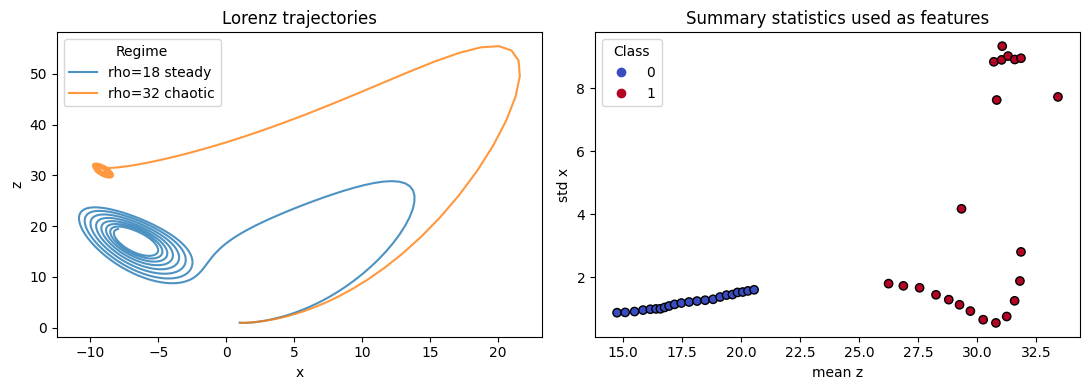

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for rho_value, label in [(18.0, "steady"), (32.0, "chaotic")]:
    traj = integrate_lorenz(rho_value, steps=700, seed=int(rho_value))
    axes[0].plot(traj[:, 0], traj[:, 2], alpha=0.8, label=f"rho={rho_value:.0f} {label}")
axes[0].set_title("Lorenz trajectories")
axes[0].set_xlabel("x")
axes[0].set_ylabel("z")
axes[0].legend(title="Regime")
scatter = axes[1].scatter(x_raw[:, 0], x_raw[:, 1], c=y, cmap="coolwarm", edgecolor="black")
axes[1].set_title("Summary statistics used as features")
axes[1].set_xlabel("mean z")
axes[1].set_ylabel("std x")
axes[1].legend(*scatter.legend_elements(), title="Class")
plt.tight_layout()
plt.show()


## Quantum-kernel package client

In [4]:
def make_quantum_kernel(n_qubits, seed):
    wires = list(range(n_qubits))
    dev = pl.device("default.qubit", wires=n_qubits, seed=seed)

    def feature_map(x):
        apply_angle_embedding(x, wires=wires)
        if n_qubits > 1:
            for left, right in zip(wires[:-1], wires[1:]):
                pl.CNOT(wires=[left, right])

    @pl.qnode(dev)
    def kernel_circuit(x1, x2):
        feature_map(x1)
        pl.adjoint(feature_map)(x2)
        return pl.probs(wires=wires)

    def kernel_value(x1, x2):
        return float(kernel_circuit(x1, x2)[0])

    return kernel_value


def kernel_matrix(a, b, kernel_value):
    return np.asarray([[kernel_value(xi, xj) for xj in b] for xi in a], dtype=float)

In [5]:
x_train, x_test, y_train, y_test, rho_train, rho_test = train_test_split(
    x_raw, y, rhos, test_size=0.3, random_state=41, stratify=y
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

kernel_value = make_quantum_kernel(n_qubits=x_train.shape[1], seed=41)
k_train = kernel_matrix(x_train, x_train, kernel_value)
k_test = kernel_matrix(x_test, x_train, kernel_value)

quantum_clf = SVC(kernel="precomputed")
quantum_clf.fit(k_train, y_train)
y_pred = quantum_clf.predict(k_test)

classical_clf = LogisticRegression(random_state=41, max_iter=1000)
classical_clf.fit(x_train, y_train)
y_classical = classical_clf.predict(x_test)

results = {
    "quantum_kernel_accuracy": accuracy_score(y_test, y_pred),
    "logistic_accuracy": accuracy_score(y_test, y_classical),
    "confusion_matrix": confusion_matrix(y_test, y_pred).astype(int).tolist(),
    "kernel_train_shape": list(k_train.shape),
    "kernel_diag_min": float(np.min(np.diag(k_train))),
    "kernel_symmetry_error": float(np.max(np.abs(k_train - k_train.T))),
}

print_section(
    "Results",
    [
        ("Quantum kernel accuracy", results["quantum_kernel_accuracy"]),
        ("Logistic accuracy", results["logistic_accuracy"]),
        ("Confusion matrix", results["confusion_matrix"]),
        ("Kernel train shape", results["kernel_train_shape"]),
        ("Kernel diagonal minimum", results["kernel_diag_min"]),
        ("Kernel symmetry error", results["kernel_symmetry_error"]),
    ],
)

Results
+-------------------------+------------------+
| Metric                  | Value            |
+-------------------------+------------------+
| Quantum kernel accuracy | 1                |
| Logistic accuracy       | 1                |
| Confusion matrix        | [[7, 0], [0, 7]] |
| Kernel train shape      | [30, 30]         |
| Kernel diagonal minimum | 1                |
| Kernel symmetry error   | 6.66134e-16      |
+-------------------------+------------------+



## Plots

The plots show Lorenz trajectory features, the quantum-kernel matrix, and held-out regime predictions ordered by the Rayleigh parameter `rho`.

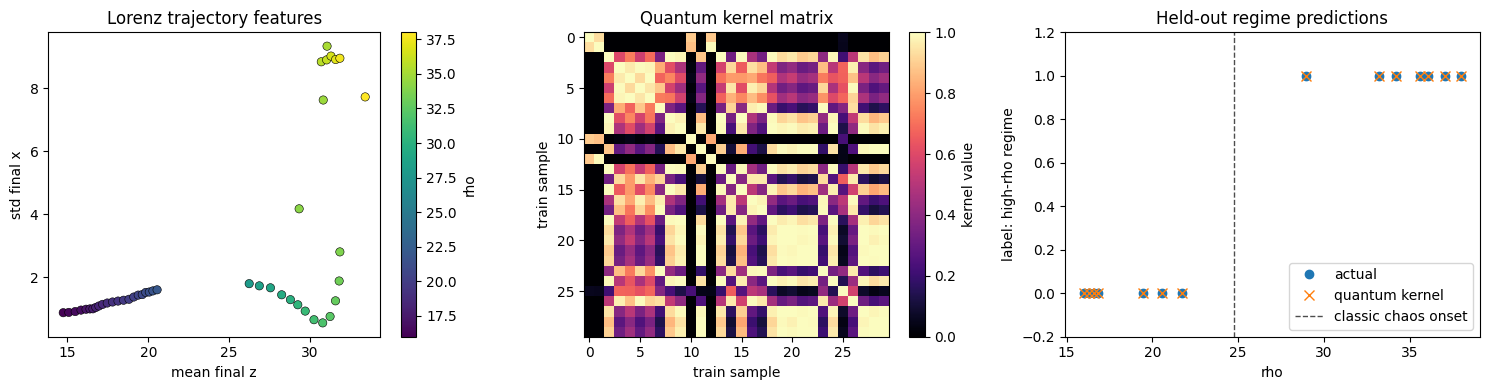

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scatter = axes[0].scatter(
    x_raw[:, 0],
    x_raw[:, 1],
    c=rhos,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.4,
)
axes[0].set_title("Lorenz trajectory features")
axes[0].set_xlabel("mean final z")
axes[0].set_ylabel("std final x")
fig.colorbar(scatter, ax=axes[0], label="rho")

im = axes[1].imshow(k_train, cmap="magma", vmin=0.0, vmax=1.0)
axes[1].set_title("Quantum kernel matrix")
axes[1].set_xlabel("train sample")
axes[1].set_ylabel("train sample")
fig.colorbar(im, ax=axes[1], label="kernel value")

order = np.argsort(rho_test)
axes[2].plot(rho_test[order], y_test[order], "o", label="actual", markersize=6)
axes[2].plot(rho_test[order], y_pred[order], "x", label="quantum kernel", markersize=7)
axes[2].axvline(24.74, color="0.3", linestyle="--", linewidth=1, label="classic chaos onset")
axes[2].set_ylim(-0.2, 1.2)
axes[2].set_title("Held-out regime predictions")
axes[2].set_xlabel("rho")
axes[2].set_ylabel("label: high-rho regime")
axes[2].legend()

fig.tight_layout()
plt.show()

## Validation block

This final cell confirms that the notebook generated Lorenz trajectory statistics, built a valid quantum kernel, and achieved non-trivial parameter-regime classification accuracy.

In [7]:
validation = {
    "dataset": {
        "problem": "lorenz_parameter_regime_classification",
        "n_samples": int(len(y)),
        "feature_names": ["mean_tail_z", "std_tail_x", "mean_abs_dx_tail"],
        "test_rhos": np.round(rho_test, 3).tolist(),
        "test_labels": y_test.astype(int).tolist(),
        "test_predictions": y_pred.astype(int).tolist(),
    },
    "results": results,
    "passed": bool(
        results["quantum_kernel_accuracy"] >= 0.85
        and results["kernel_diag_min"] > 0.99
        and results["kernel_symmetry_error"] < 1e-10
        and len(set(y_pred.tolist())) == 2
    ),
}

print("Validation")
print_section(
    "Dataset",
    [
        ("Problem", validation["dataset"]["problem"]),
        ("Samples", validation["dataset"]["n_samples"]),
        ("Feature names", validation["dataset"]["feature_names"]),
        ("Test rho values", validation["dataset"]["test_rhos"]),
        ("Test labels", validation["dataset"]["test_labels"]),
        ("Test predictions", validation["dataset"]["test_predictions"]),
    ],
)
print_section(
    "Results",
    [
        ("Quantum kernel accuracy", validation["results"]["quantum_kernel_accuracy"]),
        ("Logistic accuracy", validation["results"]["logistic_accuracy"]),
        ("Confusion matrix", validation["results"]["confusion_matrix"]),
        ("Kernel train shape", validation["results"]["kernel_train_shape"]),
        ("Kernel diagonal minimum", validation["results"]["kernel_diag_min"]),
        ("Kernel symmetry error", validation["results"]["kernel_symmetry_error"]),
    ],
)
print("Interpretation")
print(
    "The Lorenz summary features distinguish the two chosen parameter regimes for this reproducible simulator."
)
print(
    "The quantum kernel and logistic baseline are both sanity checks; this validates package usage rather than quantum advantage."
)
print()
print(f"Passed: {validation['passed']}")
assert validation["passed"]

Validation
Dataset
+------------------+---------------------------------------------------------------------------------------------------------+
| Metric           | Value                                                                                                   |
+------------------+---------------------------------------------------------------------------------------------------------+
| Problem          | lorenz_parameter_regime_classification                                                                  |
| Samples          | 44                                                                                                      |
| Feature names    | [mean_tail_z, std_tail_x, mean_abs_dx_tail]                                                             |
| Test rho values  | [16.571, 16, 19.429, 35.619, 38, 36.095, 16.286, 21.714, 37.048, 33.238, 28.952, 34.19, 16.857, 20.571] |
| Test labels      | [0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0]                             